# Process published DZ datasets

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from geoscripts.dz import dz
from geoscripts.latlon import dms2deg

In [48]:
# Domenech
meta = pd.read_excel('published_data/Domenech_ter12340-sup-0003-tables1.xlsx',header=1,index_col=0)

print(meta)

raw = pd.read_excel('published_data/Domenech_ter12340-sup-0004-tables2.xlsx',header=None,index_col=0,skiprows=1)
raw.columns = raw.iloc[0].fillna('') + ' ' + raw.iloc[1]
raw.drop(raw.iloc[0:2,:].index,inplace=True)

print(raw.columns)

       Longitude   Latitude  Elevation (m) Lithologic unit     Lithology  \
Sample                                                                     
Mi39T   8.2929ºW  30.9094ºN           1716     F5b (upper)     Sandstone   
Mi40T   8.2957ºW  30.9166ºN           1584     F5b (lower)     Sandstone   
Mi48T   8.3126ºW  30.9142ºN           1876     F5a (lower)     Sandstone   
Mi49T   8.3340ºW  30.8985ºN           2061              F3  Conglomerate   
Mi63T   8.2927ºW  30.9259ºN           1371     F5b (upper)     Sandstone   

              Depositional age  
Sample                          
Mi39T                  Carnian  
Mi40T                  Carnian  
Mi48T       Anisian to Carnian  
Mi49T   Triassic (pre‐Anisian)  
Mi63T                  Carnian  
Index([' [U] ppm', ' U/Th', ' 207/235', ' 2σ error', ' 206/238', ' 2σ error',
       ' RHO', '207/235 Age Ma', ' 2σ error', '206/238 Age (Ma)', ' 2σ error',
       '207/206 Age (Ma)', ' 2σ error', 'Best age (Ma)', ' 2σ error',
       ' 

In [49]:
# Extract individual samples and save to list
smps = []
for name in meta.index:
    print(name)
    data = raw[raw.index.str.startswith(name)]
    lat = float(meta.loc[name,'Latitude'][0:-2])
    lon = -float(meta.loc[name,'Longitude'][0:-2]) # negative for west
    smp = dz.DZSample(name=name,latlon=(lat,lon),agedata=data,color='green',source='Domenech',reported_age='P-Tr')
    smps.append(smp)

Mi39T
Mi40T
Mi48T
Mi49T
Mi63T


/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/geoscripts/dz/dz.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.agedata.loc[:,'Discordance'] = discordance
/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/geoscripts/dz/dz.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.agedata.loc[:,'Discard'] = discard
/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/geoscripts/dz/dz.py:71: SettingWith

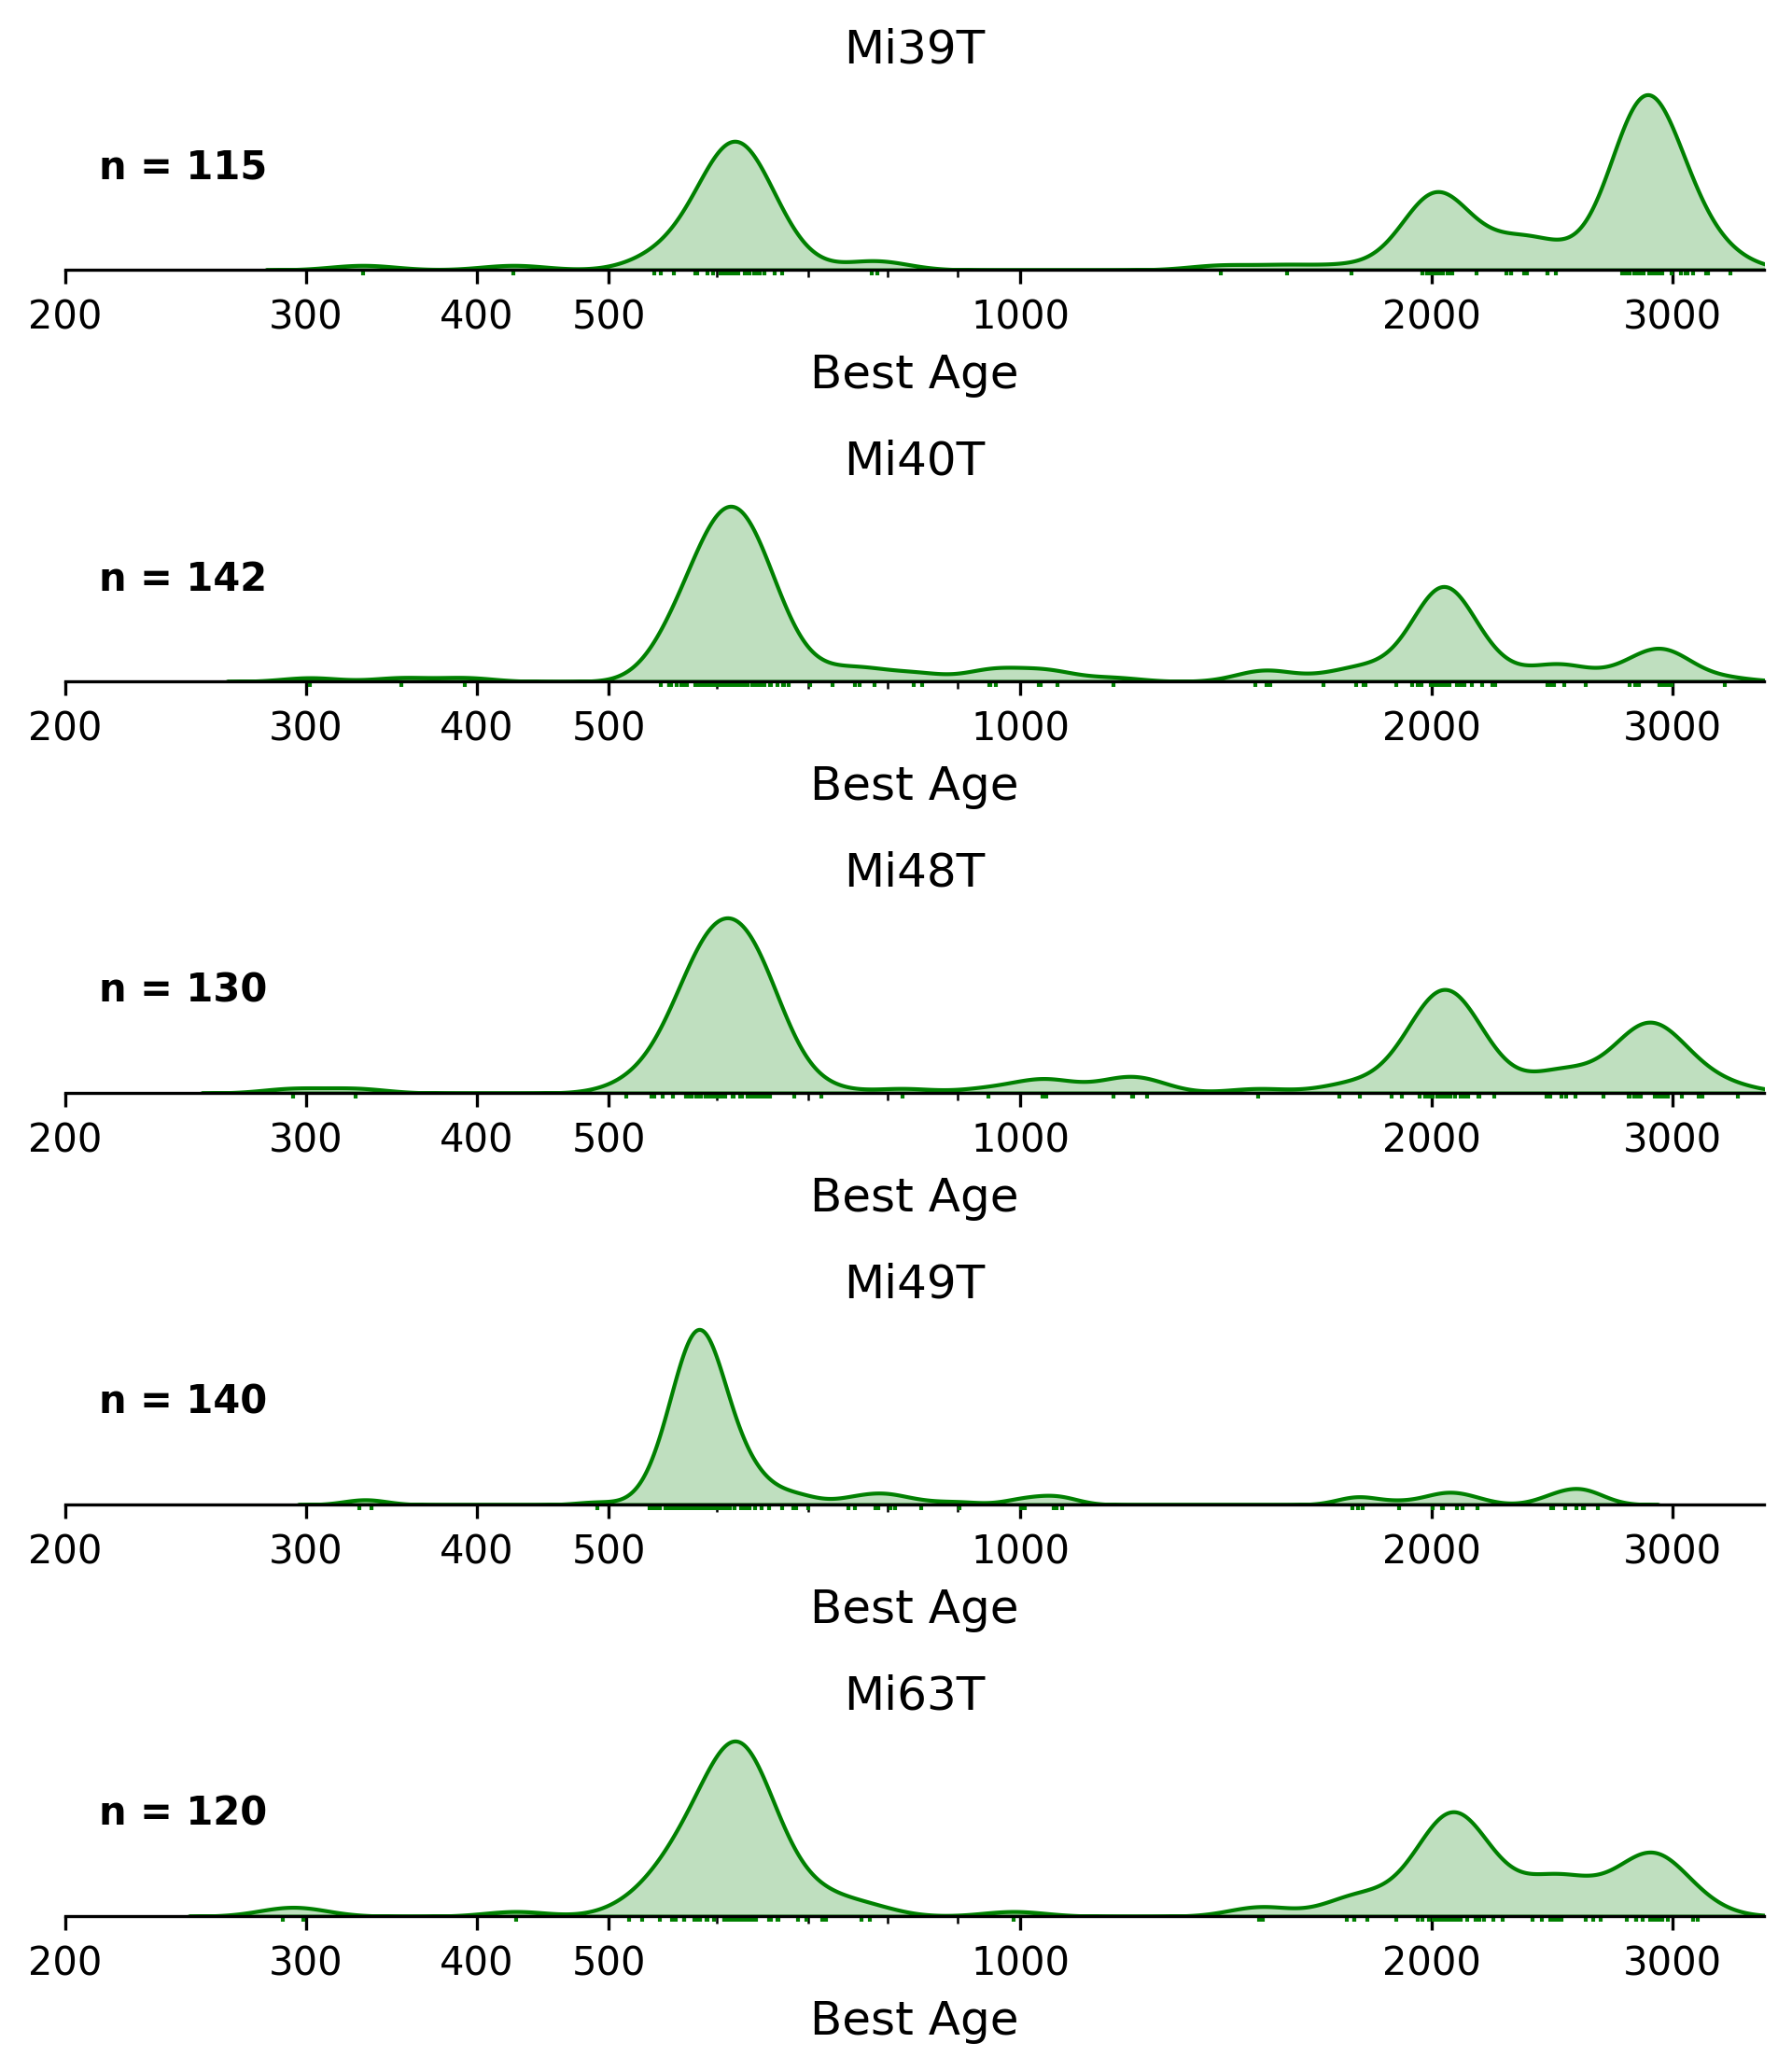

In [50]:
# Calculate best ages and plot KDEs
fig,axs = plt.subplots(len(smps),figsize=(6.5,len(smps)*1.5),dpi=300)

for k,smp in enumerate(smps):
    ax = axs[k]
    smp.calc_bestage(col_238='206/238 Age (Ma)',col_207='207/206 Age (Ma)')
    smp.bestage = smp.bestage.astype(float) # Need to fix source code so this isn't necessary
    smp.kde(ax=ax,bw_adjust=0.2)
    ax.set_xlim(200,3500)
    ax.set_title(smp.name)
    smp.save()

plt.tight_layout()
fig.savefig('Domenech_kdes.pdf')

In [51]:
# Prep data for IsoplotR
output = 'isoplotr/input_data/'
ages_df = pd.DataFrame()
os.makedirs(output,exist_ok=True)

for smp in smps:
    iso_data = smp.agedata.iloc[:,2:7]
    iso_cols = ['75','75_err','68','68_err','rho']
    iso_data.columns = iso_cols
    iso_data.to_csv(output+smp.name+'.csv',index=False)

    # Ages for detritals file
    smp_ages = smp.agedata['Best age (Ma)'].reset_index(drop=True)
    smp_ages.name = smp.name
    ages_df = pd.concat([ages_df,smp_ages],axis=1)


ages_df.to_csv(output+'domenech_ages.csv',index=False)

In [52]:
# Perez
meta = pd.read_excel('published_data/Perez_tect21081-sup-0002-tect21081-sup-0001-2018tc005413-s01-s02_rev.xlsx',header=0,index_col=0,sheet_name='TABLE S1 Location Information')

print(meta)

raw = pd.read_excel('published_data/Perez_tect21081-sup-0002-tect21081-sup-0001-2018tc005413-s01-s02_rev.xlsx',header=None,index_col=0,sheet_name='TABLE S2 Zircon U-Pb results')
raw.columns = raw.iloc[0].fillna('') + ' ' + raw.iloc[1]
raw.drop(raw.iloc[0:2,:].index,inplace=True)
raw.dropna(how='all',inplace=True)

print(raw.columns)

                 Region   Latitude  Longitude   Age, Formation  \
Sample Name                                                      
01MCO        High Atlas  31.302239  -7.397644       Ouarzazate   
02MCO        High Atlas  31.299927  -7.390774         Cambrian   
03MCO        High Atlas  31.314573  -7.374777       Ordovician   
04MCO        High Atlas  31.319265  -7.378882       Ordovician   
05MCO        High Atlas  31.282763  -7.585985         Cambrian   
06MCO        High Atlas  31.285780  -7.590401     Triassic F5    
07MCO        High Atlas  31.297929  -7.589787     Triassic F3    
08MCO        High Atlas  31.311378  -7.561911     Triassic F5    
09MCO        High Atlas  31.309353  -7.601391     Triassic F5    
10MCO        High Atlas  31.354861  -7.756812     Triassic F3    
11MCO        High Atlas  31.353003  -7.756067       Permian F2   
12MCO        High Atlas  31.323831  -7.758938    Carboniferous   
13MCO        High Atlas  31.212034  -7.849956     Triassic F5    
14MCO     

In [53]:
# Extract individual samples and save to list
smps = []
for name in meta.index:
    print(name)
    data = raw[raw.index.str.contains(name)]
    lat = float(meta.loc[name,'Latitude'])
    lon = float(meta.loc[name,'Longitude'])
    ptr = ('Triassic' in meta.loc[name,'Age, Formation'])|('Permian' in meta.loc[name,'Age, Formation'])
    ptr_dict = {True:'P-Tr',False:'Other'}
    smp = dz.DZSample(name=name,latlon=(lat,lon),agedata=data,color='red',source='Perez',reported_age=ptr_dict[ptr])
    smps.append(smp)

01MCO
02MCO
03MCO
04MCO
05MCO
06MCO
07MCO
08MCO
09MCO
10MCO
11MCO
12MCO
13MCO
14MCO
15MCO
16MCO


/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/geoscripts/dz/dz.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.agedata.loc[:,'Discordance'] = discordance
/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/geoscripts/dz/dz.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.agedata.loc[:,'Discard'] = discard
/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/geoscripts/dz/dz.py:71: SettingWith

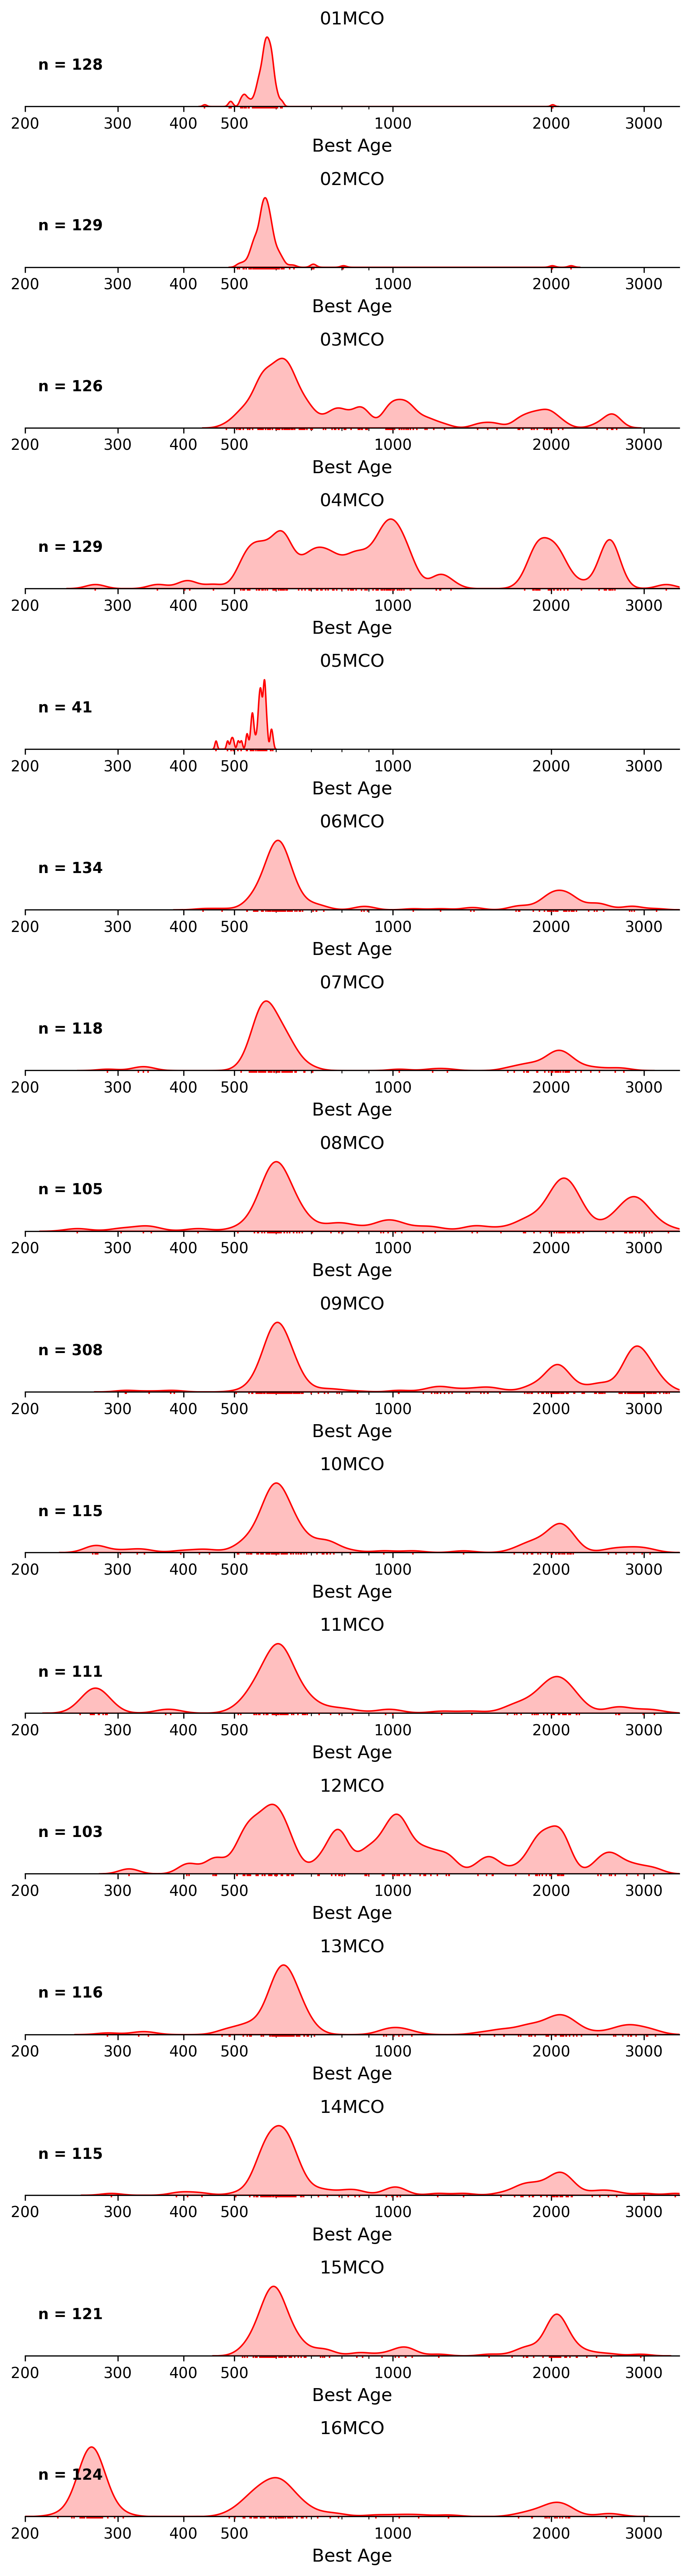

In [54]:
# Calculate best ages and plot KDEs
fig,axs = plt.subplots(len(smps),figsize=(6.5,len(smps)*1.5),dpi=300)

for k,smp in enumerate(smps):
    ax = axs[k]
    smp.calc_bestage(col_238='206/238  Age (Ma)',col_207='207/206 Age (Ma)')
    smp.bestage = smp.bestage.astype(float) # Need to fix source code so this isn't necessary
    smp.kde(ax=ax,bw_adjust=0.2)
    ax.set_xlim(200,3500)
    ax.set_title(smp.name)
    smp.save()

plt.tight_layout()
fig.savefig('Perez_kdes.pdf')

In [55]:
# Prep data for IsoplotR
output = 'isoplotr/input_data/'
ages_df = pd.DataFrame()
os.makedirs(output,exist_ok=True)

for smp in smps:
    iso_data = smp.agedata.iloc[:,2:7]
    iso_cols = ['75','75_err','68','68_err','rho']
    iso_data.columns = iso_cols
    iso_data.to_csv(output+smp.name+'.csv',index=False)

    # Ages for detritals file
    smp_ages = smp.agedata['Best age (Ma)'].reset_index(drop=True)
    smp_ages.name = smp.name
    ages_df = pd.concat([ages_df,smp_ages],axis=1)


ages_df.to_csv(output+'perez_ages.csv',index=False)

In [56]:
# Marzoli - get metadata
meta = pd.read_csv('published_data/Marzoli_locations.csv',header=0,index_col=0)

print(meta)

raw_path = 'published_data/Marzoli_1-s2.0-S0024493717300312-mmc2.xlsx'
sheets = pd.ExcelFile(raw_path).sheet_names
print(sheets)

         Latitude  Longitude
Sample                      
HAJ     31 0.7 74   -7 22 70
A        31 35 48   -7 25 46
S        31 35 48   -7 25 46
Ar       30 41 33   -9 13 44
L2       31 32 50   -7 40 20
L3       31 32 50   -7 40 20
M1       31 32 50   -7 40 20
M2       31 32 50   -7 40 20
BH20     44 45 24  -66 50 08
['Tiourjdal-HAJ', 'Argana-Ar', 'Ait Ourir-M1', 'Ait Ourir-M2', 'Ait Ourir-L2', 'Ait Ourir-L3', 'Jebel Imizar-A', 'Jebel Imizar-S', 'Grand Manan-BH20']


In [57]:
# Marzoli - create DZ objects
smps = []
for name in meta.index:
    print(name)
    sheet = [sheet for sheet in sheets if sheet.endswith('-'+name)][0]
    print(sheet)
    raw = pd.read_excel(raw_path,header=None,sheet_name=sheet,skiprows=1)
    raw.columns = raw.iloc[0].fillna('') + ' ' + raw.iloc[1]
    raw.drop(raw.iloc[0:2,:].index,inplace=True)
    
    lat_dms = meta.loc[name,'Latitude'].split(' ')
    lon_dms = meta.loc[name,'Longitude'].split(' ')

    lat_dms = [float(x) for x in lat_dms]
    lon_dms = [float(x) for x in lon_dms]

    lat,lon = dms2deg(latdeg=lat_dms[0],londeg=lon_dms[0],latmin=lat_dms[1],lonmin=lon_dms[1],
                      latsec=lat_dms[2],lonsec=lon_dms[2])
    print(lat,lon)

    smp = dz.DZSample(name=name,latlon=(lat,lon),agedata=raw,color='orange',source='Marzoli',reported_age='P-Tr')
    smps.append(smp)

HAJ
Tiourjdal-HAJ
31.032222222222224 -7.386111111111111
A
Jebel Imizar-A
31.596666666666668 -7.429444444444444
S
Jebel Imizar-S
31.596666666666668 -7.429444444444444
Ar
Argana-Ar
30.6925 -9.22888888888889
L2
Ait Ourir-L2
31.54722222222222 -7.6722222222222225
L3
Ait Ourir-L3
31.54722222222222 -7.6722222222222225
M1
Ait Ourir-M1
31.54722222222222 -7.6722222222222225
M2
Ait Ourir-M2
31.54722222222222 -7.6722222222222225
BH20
Grand Manan-BH20
44.75666666666667 -66.83555555555556


2      587.314492
3      587.011382
4      592.481060
5      601.010269
6      598.516316
7      604.333407
8      607.137847
9      611.872311
10     612.200100
11     638.723709
12     641.038631
13     640.535028
14     659.504724
15     679.663229
16     745.529165
17     795.498636
18     819.998686
19     876.082593
20    1135.612995
21    1178.715121
22    2178.102424
23    2586.415271
24    3087.328957
25     516.483127
26     559.407486
27     572.840401
28     606.821200
29     610.682472
30     621.519545
31     620.858451
32     626.801598
33     644.687907
34     962.046439
35    1200.327380
36    2036.958373
37     528.004387
38     560.198071
39     562.702666
40     580.922291
41     591.463895
42     599.473133
43     609.345885
44     614.216041
45     657.034156
46     693.745841
47     575.195283
48     574.660352
49     597.833893
50     612.423354
51     624.209255
52     630.974999
53     649.369015
54     835.893144
55    1032.172764
56    1058.577034
57    2084

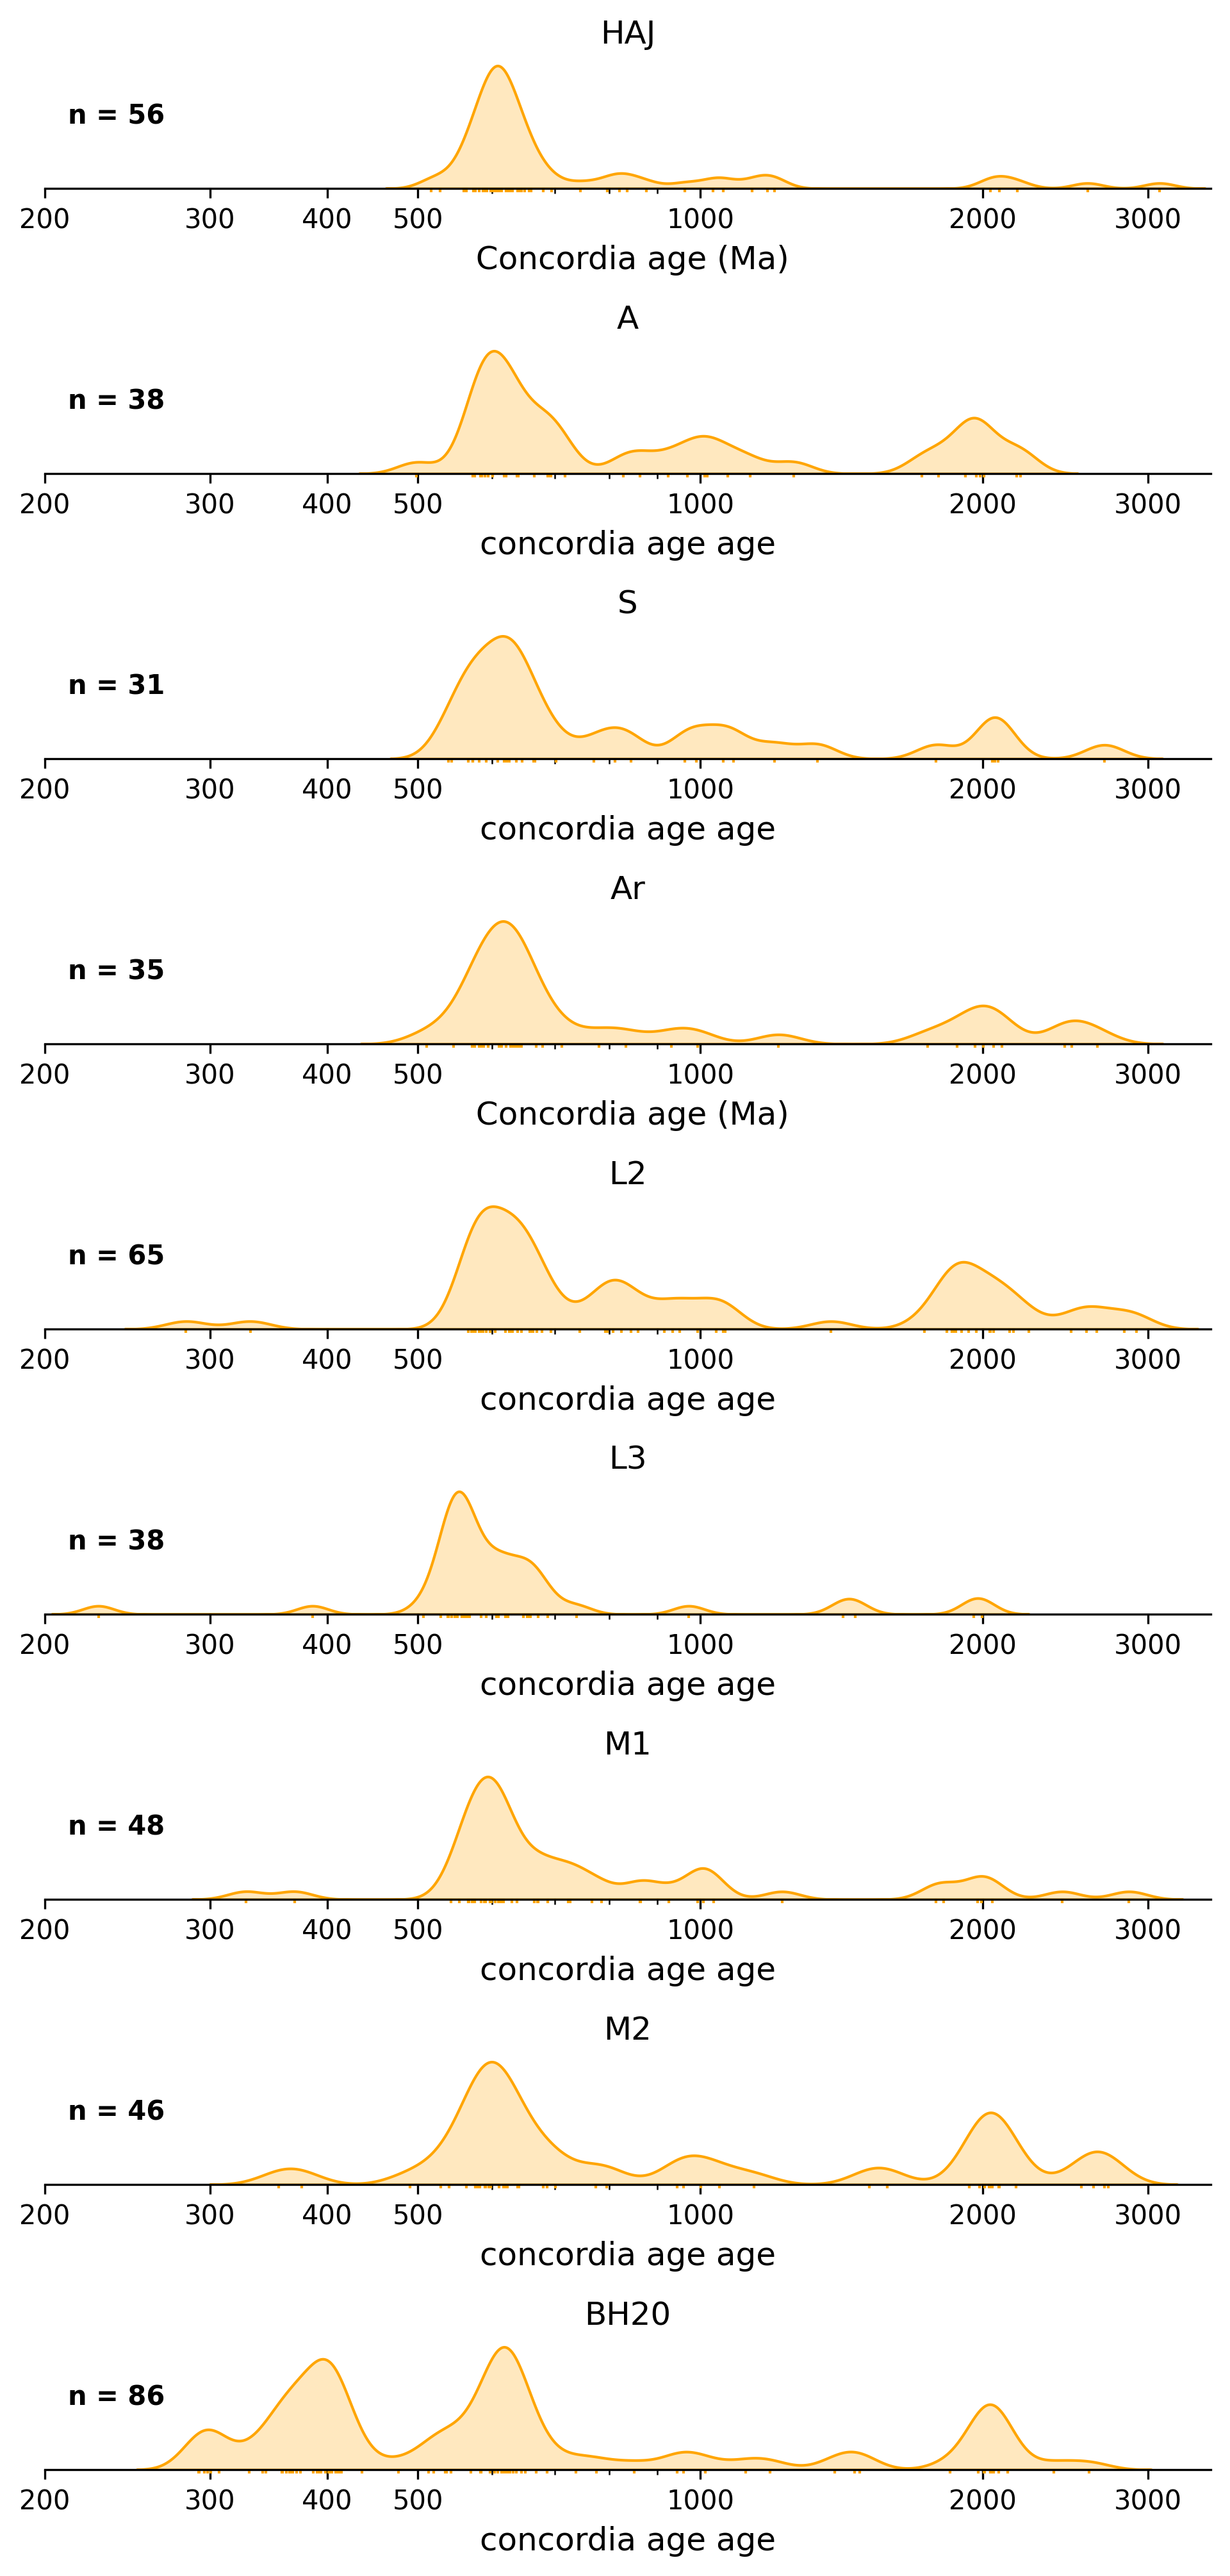

In [58]:
# Plot and save samples (using concordia ages as best ages for now)
fig,axs = plt.subplots(len(smps),figsize=(6.5,len(smps)*1.5),dpi=300)
for k,smp in enumerate(smps):
    ax = axs[k]
    conc_col = [col for col in smp.agedata.columns if ('Concordia' in str(col))|('concordia' in str(col))][0]
    conc_ages = smp.agedata[conc_col]
    smp.bestage = conc_ages[conc_ages!='Discordant'].astype(float).dropna()
    print(smp.bestage)
    smp.kde(ax=ax,bw_adjust=0.2,add_n=True)
    ax.set_xlim(200,3500)
    ax.set_title(smp.name)
    smp.save()

fig.tight_layout()
fig.savefig('marzoli_kdes.pdf')


In [59]:
# Prep data for IsoplotR (concordia ages only for now)
output = 'isoplotr/input_data/'
ages_df = pd.DataFrame()
os.makedirs(output,exist_ok=True)

for smp in smps:
    #iso_data = smp.agedata.iloc[:,2:7]
    #iso_cols = ['75','75_err','68','68_err','rho']
    #iso_data.columns = iso_cols
    #iso_data.to_csv(output+smp.name+'.csv',index=False)

    # Ages for detritals file
    smp_ages = smp.bestage.reset_index(drop=True)
    smp_ages.name = smp.name
    ages_df = pd.concat([ages_df,smp_ages],axis=1)


ages_df.to_csv(output+'marzoli_ages.csv',index=False)